Starting New Week Research: Cliff-Hanger Experiments on cpu...
Testing 5 Depths across 6 Widths...
  > Testing Depth 20 / Width 16... Accuracy: 89.03%
  > Testing Depth 20 / Width 32... Accuracy: 93.22%
  > Testing Depth 20 / Width 64... Accuracy: 95.45%
  > Testing Depth 20 / Width 128... Accuracy: 76.54%
  > Testing Depth 20 / Width 256... Accuracy: 90.29%
  > Testing Depth 20 / Width 512... Accuracy: 91.72%
  > Testing Depth 22 / Width 16... Accuracy: 89.38%
  > Testing Depth 22 / Width 32... Accuracy: 85.71%
  > Testing Depth 22 / Width 64... Accuracy: 88.42%
  > Testing Depth 22 / Width 128... Accuracy: 80.20%
  > Testing Depth 22 / Width 256... Accuracy: 11.35%
  > Testing Depth 22 / Width 512... Accuracy: 11.35%
  > Testing Depth 23 / Width 16... Accuracy: 87.59%
  > Testing Depth 23 / Width 32... Accuracy: 89.08%
  > Testing Depth 23 / Width 64... Accuracy: 89.97%
  > Testing Depth 23 / Width 128... Accuracy: 11.35%
  > Testing Depth 23 / Width 256... Accuracy: 11.35%
  > Testi

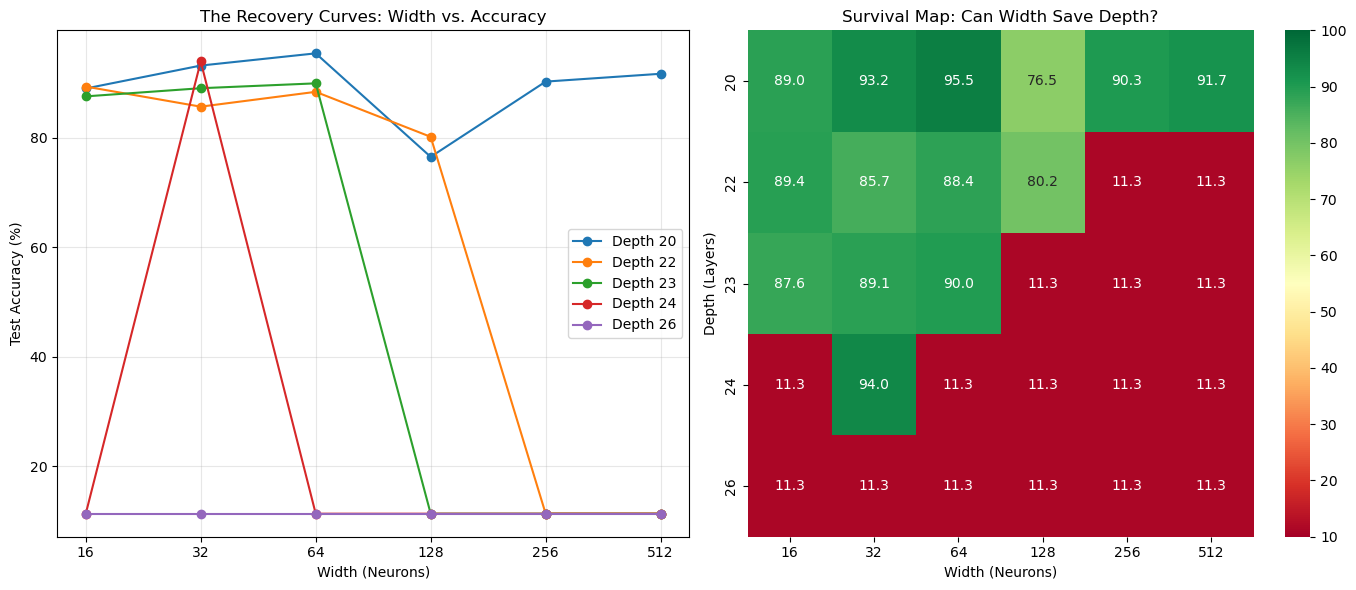


DATA FOR PLOT: Cliff Hanger (Depth x Width)
dataset  depth  width  accuracy
  MNIST     20     16     89.03
  MNIST     20     32     93.22
  MNIST     20     64     95.45
  MNIST     20    128     76.54
  MNIST     20    256     90.29
  MNIST     20    512     91.72
  MNIST     22     16     89.38
  MNIST     22     32     85.71
  MNIST     22     64     88.42
  MNIST     22    128     80.20
  MNIST     22    256     11.35
  MNIST     22    512     11.35
  MNIST     23     16     87.59
  MNIST     23     32     89.08
  MNIST     23     64     89.97
  MNIST     23    128     11.35
  MNIST     23    256     11.35
  MNIST     23    512     11.35
  MNIST     24     16     11.35
  MNIST     24     32     93.97
  MNIST     24     64     11.35
  MNIST     24    128     11.35
  MNIST     24    256     11.35
  MNIST     24    512     11.35
  MNIST     26     16     11.35
  MNIST     26     32     11.35
  MNIST     26     64     11.35
  MNIST     26    128     11.35
  MNIST     26    256     1

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- CONFIG ----------
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHS = 10
BATCH = 256
LR = 1e-3

# The "Danger Zone" Sweeps
# We test Depth 20 (Wobbly), 22 (Dying), 23 (Critical), 24 (Dead)
DEPTHS_TO_TEST = [20, 22, 23, 24, 26] 
WIDTHS_TO_TEST = [16, 32, 64, 128, 256, 512]

print(f"Starting New Week Research: Cliff-Hanger Experiments on {DEVICE}...")

# ---------- SETUP ----------
def get_loaders():
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
    train_set = datasets.MNIST('./data', train=True, download=True, transform=transform)
    test_set = datasets.MNIST('./data', train=False, transform=transform)
    return DataLoader(train_set, batch_size=BATCH, shuffle=True), DataLoader(test_set, batch_size=BATCH, shuffle=False), 28*28

class DynamicMLP(nn.Module):
    def __init__(self, depth, width, input_dim, num_classes=10):
        super().__init__()
        layers = [nn.Flatten(), nn.Linear(input_dim, width), nn.ReLU()]
        for _ in range(depth - 2):
            layers.append(nn.Linear(width, width))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(width, num_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

def train_and_eval(depth, width):
    # Set seed for reproducibility
    torch.manual_seed(42) 
    
    train_loader, test_loader, input_dim = get_loaders()
    model = DynamicMLP(depth, width, input_dim).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()
    
    model.train()
    for _ in range(EPOCHS):
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            _, pred = torch.max(out, 1)
            total += y.size(0)
            correct += (pred == y).sum().item()
    return 100 * correct / total

# ---------- MAIN LOOP ----------
results = []

print(f"Testing {len(DEPTHS_TO_TEST)} Depths across {len(WIDTHS_TO_TEST)} Widths...")

for d in DEPTHS_TO_TEST:
    for w in WIDTHS_TO_TEST:
        print(f"  > Testing Depth {d} / Width {w}...", end=" ")
        acc = train_and_eval(d, w)
        print(f"Accuracy: {acc:.2f}%")
        
        results.append({
            'dataset': 'MNIST',
            'depth': d,
            'width': w,
            'accuracy': acc
        })

# ---------- VISUALIZATION ----------
df = pd.DataFrame(results)

plt.figure(figsize=(14, 6))

# Plot 1: The Line Graph (Recovery Curves)
# This is the specific graph you asked for: Width vs Accuracy
plt.subplot(1, 2, 1)
for d in DEPTHS_TO_TEST:
    subset = df[df['depth'] == d]
    plt.plot(subset['width'], subset['accuracy'], marker='o', label=f'Depth {d}')

plt.xscale('log', base=2)
plt.xticks(WIDTHS_TO_TEST, labels=[str(w) for w in WIDTHS_TO_TEST])
plt.xlabel("Width (Neurons)")
plt.ylabel("Test Accuracy (%)")
plt.title("The Recovery Curves: Width vs. Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: The Heatmap (Survival Zone)
plt.subplot(1, 2, 2)
heatmap_data = df.pivot(index='depth', columns='width', values='accuracy')
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="RdYlGn", vmin=10, vmax=100)
plt.title("Survival Map: Can Width Save Depth?")
plt.ylabel("Depth (Layers)")
plt.xlabel("Width (Neurons)")

plt.tight_layout()
plt.show()

# ---------- PRINT DATA TABLE (FOR ANALYSIS) ----------
print("\n" + "="*50)
print("DATA FOR PLOT: Cliff Hanger (Depth x Width)")
print("="*50)
print(df[['dataset', 'depth', 'width', 'accuracy']].to_string(index=False))

Generating Phase Diagram on cpu...
Sweeping 42 configurations...
Testing Depth 10 | Width 16... Acc: 88.9%
Testing Depth 10 | Width 32... Acc: 92.2%
Testing Depth 10 | Width 64... Acc: 95.1%
Testing Depth 10 | Width 128... Acc: 96.4%
Testing Depth 10 | Width 256... Acc: 97.6%
Testing Depth 10 | Width 512... Acc: 97.5%
Testing Depth 15 | Width 16... Acc: 78.8%
Testing Depth 15 | Width 32... Acc: 89.4%
Testing Depth 15 | Width 64... Acc: 94.3%
Testing Depth 15 | Width 128... Acc: 96.1%
Testing Depth 15 | Width 256... Acc: 95.4%
Testing Depth 15 | Width 512... Acc: 79.3%
Testing Depth 20 | Width 16... Acc: 79.2%
Testing Depth 20 | Width 32... Acc: 89.8%
Testing Depth 20 | Width 64... Acc: 93.8%
Testing Depth 20 | Width 128... Acc: 76.4%
Testing Depth 20 | Width 256... Acc: 88.9%
Testing Depth 20 | Width 512... Acc: 75.7%
Testing Depth 25 | Width 16... Acc: 11.3%
Testing Depth 25 | Width 32... Acc: 11.3%
Testing Depth 25 | Width 64... Acc: 11.3%
Testing Depth 25 | Width 128... Acc: 11.3%
T

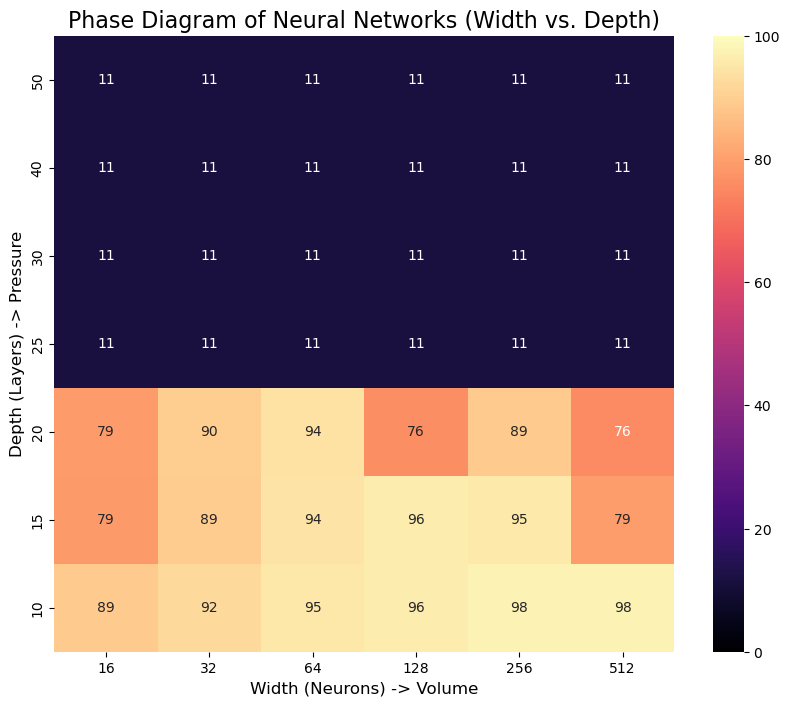


PHASE DIAGRAM DATA
 Depth  Width  Accuracy
    10     16     88.89
    10     32     92.19
    10     64     95.08
    10    128     96.44
    10    256     97.57
    10    512     97.53
    15     16     78.77
    15     32     89.43
    15     64     94.28
    15    128     96.13
    15    256     95.43
    15    512     79.33
    20     16     79.15
    20     32     89.81
    20     64     93.80
    20    128     76.39
    20    256     88.92
    20    512     75.67
    25     16     11.35
    25     32     11.35
    25     64     11.35
    25    128     11.35
    25    256     11.35
    25    512     11.35
    30     16     11.35
    30     32     11.35
    30     64     11.35
    30    128     11.35
    30    256     11.35
    30    512     11.35
    40     16     11.35
    40     32     11.35
    40     64     11.35
    40    128     11.35
    40    256     11.35
    40    512     11.35
    50     16     11.35
    50     32     11.35
    50     64     11.35
    50    128     11

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- CONFIG ----------
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHS = 5  # Reduced epochs for speed (we just need to check trainability, not perfect convergence)
BATCH = 256
LR = 1e-3

# The "Grand Sweep" Grid
# We need a wide range to see the curve
DEPTHS = [10, 15, 20, 25, 30, 40, 50] 
WIDTHS = [16, 32, 64, 128, 256, 512]

print(f"Generating Phase Diagram on {DEVICE}...")

# ---------- SETUP ----------
def get_loaders():
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
    train_set = datasets.MNIST('./data', train=True, download=True, transform=transform)
    test_set = datasets.MNIST('./data', train=False, transform=transform)
    return DataLoader(train_set, batch_size=BATCH, shuffle=True), DataLoader(test_set, batch_size=BATCH, shuffle=False), 28*28

class DynamicMLP(nn.Module):
    def __init__(self, depth, width, input_dim, num_classes=10):
        super().__init__()
        layers = [nn.Flatten(), nn.Linear(input_dim, width), nn.ReLU()]
        for _ in range(depth - 2):
            layers.append(nn.Linear(width, width))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(width, num_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

def train_and_eval(depth, width):
    # Fixed seed to ensure the phase boundary is consistent
    torch.manual_seed(42) 
    
    train_loader, test_loader, input_dim = get_loaders()
    model = DynamicMLP(depth, width, input_dim).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()
    
    model.train()
    for _ in range(EPOCHS):
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            _, pred = torch.max(out, 1)
            total += y.size(0)
            correct += (pred == y).sum().item()
    return 100 * correct / total

# ---------- MAIN LOOP ----------
results = []
print(f"Sweeping {len(DEPTHS) * len(WIDTHS)} configurations...")

for d in DEPTHS:
    for w in WIDTHS:
        print(f"Testing Depth {d} | Width {w}...", end=" ")
        try:
            acc = train_and_eval(d, w)
            print(f"Acc: {acc:.1f}%")
        except Exception as e:
            print(f"Failed: {e}")
            acc = 0.0
            
        results.append({
            'Depth': d,
            'Width': w,
            'Accuracy': acc
        })

# ---------- VISUALIZATION (THE PHASE DIAGRAM) ----------
df = pd.DataFrame(results)
heatmap_data = df.pivot(index='Depth', columns='Width', values='Accuracy')

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="magma", vmin=0, vmax=100)

# Inverting Y-axis so Depth 10 is at the top (like a standard plot)
plt.gca().invert_yaxis()

plt.title("Phase Diagram of Neural Networks (Width vs. Depth)", fontsize=16)
plt.ylabel("Depth (Layers) -> Pressure", fontsize=12)
plt.xlabel("Width (Neurons) -> Volume", fontsize=12)

# Adding the 'Phase Boundary' annotation manually usually works best in post-processing,
# but the color gradient will show it clearly.
plt.show()

# ---------- PRINT DATA TABLE ----------
print("\n" + "="*50)
print("PHASE DIAGRAM DATA")
print("="*50)
print(df.to_string(index=False))


[1] Training small (3-layer) model...
  Epoch 1: accuracy = 95.94%
  Epoch 2: accuracy = 96.47%
  Epoch 3: accuracy = 97.00%
  Final small model accuracy: 97.00%

[2] Creating Point A (deep identity-grafted model)...
  Point A accuracy: 95.68% (should match small model)

[3] Creating Point B (random deep model)...
  Point B accuracy: 14.54% (~10%)

[4] Linear interpolation A → B...
  α=0.00 | loss=0.2204 | acc=95.68%
  α=0.05 | loss=0.2560 | acc=95.67%
  α=0.11 | loss=0.3030 | acc=95.63%
  α=0.16 | loss=0.3639 | acc=95.55%
  α=0.21 | loss=0.4410 | acc=95.39%
  α=0.26 | loss=0.5364 | acc=95.11%
  α=0.32 | loss=0.6515 | acc=94.74%
  α=0.37 | loss=0.7861 | acc=93.84%
  α=0.42 | loss=0.9385 | acc=92.39%
  α=0.47 | loss=1.1046 | acc=89.58%
  α=0.53 | loss=1.2788 | acc=85.64%
  α=0.58 | loss=1.4545 | acc=81.02%
  α=0.63 | loss=1.6247 | acc=75.21%
  α=0.68 | loss=1.7833 | acc=67.52%
  α=0.74 | loss=1.9249 | acc=56.10%
  α=0.79 | loss=2.0456 | acc=42.05%
  α=0.84 | loss=2.1428 | acc=30.38%
  

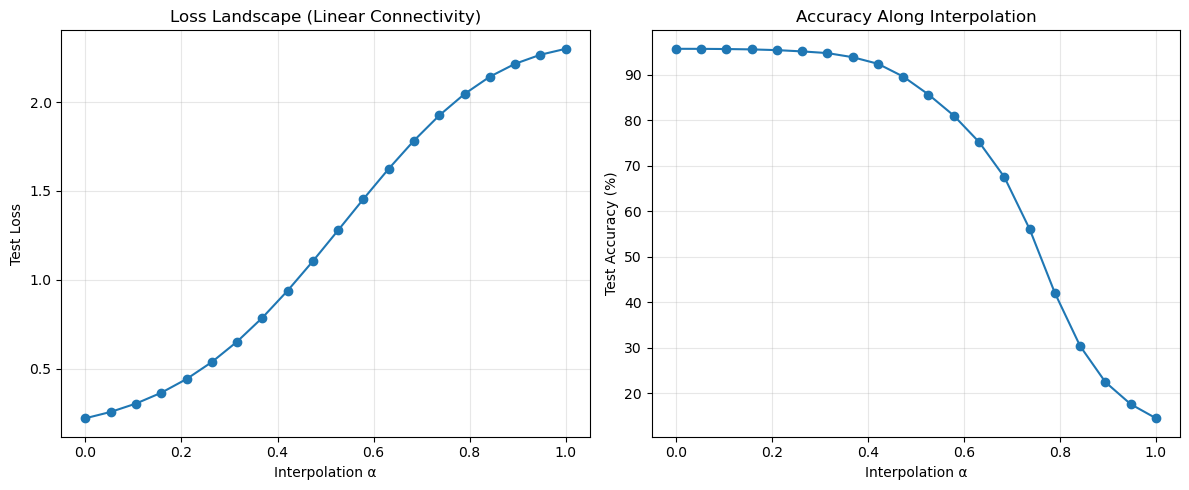

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 64
WIDTH = 128
DEPTH_SMALL = 3
DEPTH_LARGE = 50
ALPHA_STEPS = 20
EPOCHS = 3

torch.manual_seed(0)
np.random.seed(0)

# ---------------- DATA ----------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_loader = DataLoader(
    datasets.MNIST("./data", train=True, download=True, transform=transform),
    batch_size=BATCH_SIZE, shuffle=True
)

test_loader = DataLoader(
    datasets.MNIST("./data", train=False, transform=transform),
    batch_size=1000, shuffle=False
)

# ---------------- MODELS ----------------
class ResidualBlock(nn.Module):
    """
    Identity-preserving residual block.
    Initialized to exact identity.
    """
    def __init__(self, width):
        super().__init__()
        self.linear = nn.Linear(width, width)
        nn.init.zeros_(self.linear.weight)
        nn.init.zeros_(self.linear.bias)

    def forward(self, x):
        return x + self.linear(x)


class ResidualMLP(nn.Module):
    def __init__(self, depth, width):
        super().__init__()
        self.flatten = nn.Flatten()
        self.input = nn.Linear(28 * 28, width)
        self.relu = nn.ReLU()
        self.blocks = nn.ModuleList(
            [ResidualBlock(width) for _ in range(depth - 2)]
        )
        self.output = nn.Linear(width, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.input(x))
        for block in self.blocks:
            x = block(x)
        return self.output(x)


# ---------------- EVAL ----------------
def evaluate(model):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    loss, correct = 0.0, 0

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            loss += criterion(out, y).item()
            correct += (out.argmax(dim=1) == y).sum().item()

    loss /= len(test_loader)
    acc = 100 * correct / len(test_loader.dataset)
    return loss, acc


# ---------------- STEP 1: TRAIN SMALL MODEL ----------------
print("\n[1] Training small (3-layer) model...")
small_model = ResidualMLP(DEPTH_SMALL, WIDTH).to(DEVICE)
opt = optim.Adam(small_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(EPOCHS):
    small_model.train()
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        loss = criterion(small_model(x), y)
        loss.backward()
        opt.step()

    _, acc = evaluate(small_model)
    print(f"  Epoch {epoch+1}: accuracy = {acc:.2f}%")

small_loss, small_acc = evaluate(small_model)
print(f"  Final small model accuracy: {small_acc:.2f}%")


# ---------------- STEP 2: POINT A (GRAFTED DEEP MODEL) ----------------
print("\n[2] Creating Point A (deep identity-grafted model)...")
model_A = ResidualMLP(DEPTH_LARGE, WIDTH).to(DEVICE)

# Copy input/output layers
model_A.input.load_state_dict(small_model.input.state_dict())
model_A.output.load_state_dict(small_model.output.state_dict())

loss_A, acc_A = evaluate(model_A)
print(f"  Point A accuracy: {acc_A:.2f}% (should match small model)")


# ---------------- STEP 3: POINT B (RANDOM DEEP MODEL) ----------------
print("\n[3] Creating Point B (random deep model)...")
model_B = ResidualMLP(DEPTH_LARGE, WIDTH).to(DEVICE)

loss_B, acc_B = evaluate(model_B)
print(f"  Point B accuracy: {acc_B:.2f}% (~10%)")


# ---------------- STEP 4: LINEAR INTERPOLATION ----------------
print("\n[4] Linear interpolation A → B...")
alphas = np.linspace(0, 1, ALPHA_STEPS)
losses, accuracies = [], []

model_mix = ResidualMLP(DEPTH_LARGE, WIDTH).to(DEVICE)

for alpha in alphas:
    with torch.no_grad():
        for p_mix, p_A, p_B in zip(
            model_mix.parameters(),
            model_A.parameters(),
            model_B.parameters()
        ):
            p_mix.copy_((1 - alpha) * p_A + alpha * p_B)

    loss, acc = evaluate(model_mix)
    losses.append(loss)
    accuracies.append(acc)

    print(f"  α={alpha:.2f} | loss={loss:.4f} | acc={acc:.2f}%")


# ---------------- PLOTS ----------------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(alphas, losses, marker="o")
plt.xlabel("Interpolation α")
plt.ylabel("Test Loss")
plt.title("Loss Landscape (Linear Connectivity)")
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(alphas, accuracies, marker="o")
plt.xlabel("Interpolation α")
plt.ylabel("Test Accuracy (%)")
plt.title("Accuracy Along Interpolation")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
